Cargando imágenes...


Cargando cardboard:   0%|          | 0/403 [00:00<?, ?img/s]

Cargando glass:   0%|          | 0/501 [00:00<?, ?img/s]

Cargando metal:   0%|          | 0/410 [00:00<?, ?img/s]

Cargando paper:   0%|          | 0/594 [00:00<?, ?img/s]

...

 Non-trainable params: 448 (1.75 KB)


🚀 Entrenando CNN PRO (con Augmentation) SIN ReduceLROnPlateau...


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]


 RESULTADOS PARA EL README 
Modelo: CNN Avanzada (Augmentation, sin ReduceLR)
Parámetros totales: 111430
Accuracy Train: 0.9413
Accuracy Val:   0.8241
Accuracy Test:  0.8281


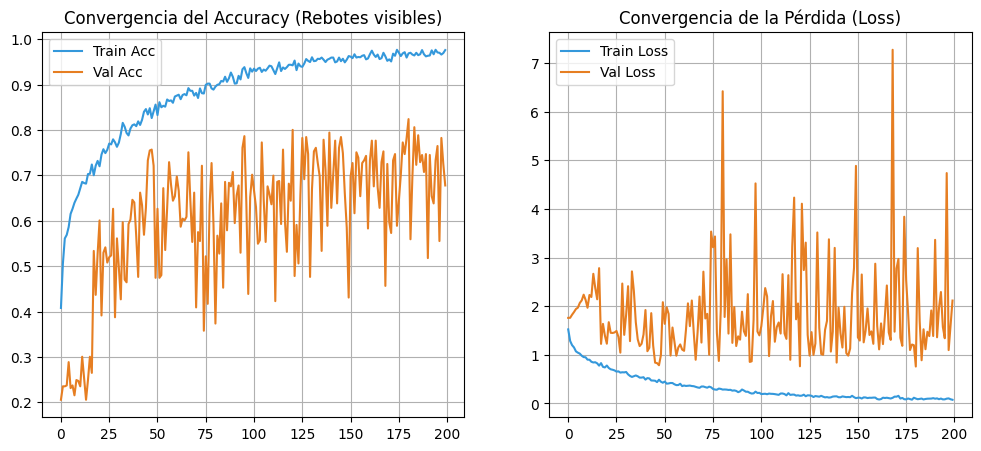

In [ ]:
import sys
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image # <--- ¡ESTO FALTABA!
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from tqdm.keras import TqdmCallback
from tqdm.notebook import tqdm

# 1. IMPORTAR EL MODELO
sys.path.append(os.path.abspath('.'))
from modelos.modelo_cnn_avanzado import obtener_modelo_avanzado

# =========================================================
# 2. CARGAR Y PREPARAR LOS DATOS
# =========================================================
# COMPRUEBA QUE ESTA RUTA SEA CORRECTA EN TU ORDENADOR
PATH_DATOS = 'data/' 
IMG_SIZE = (64, 64) 

def cargar_datos(path):
    X_list, y_list = [], []
    if not os.path.exists(path):
        print(f"❌ ERROR CRÍTICO: La carpeta '{path}' no existe en esta ruta: {os.path.abspath(path)}")
        return np.array([]), np.array([]), []
        
    categorias = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])
    
    if len(categorias) == 0:
        print(f"❌ ERROR: La carpeta '{path}' existe, pero no tiene subcarpetas dentro.")
        return np.array([]), np.array([]), []

    for idx, cat in enumerate(categorias):
        files = glob.glob(os.path.join(path, cat, '*'))
        for f in tqdm(files, desc=f"Cargando {cat}", unit="img"):
            try:
                img = Image.open(f).convert('RGB').resize(IMG_SIZE)
                X_list.append(np.array(img))
                y_list.append(idx)
            except Exception as e:
                # Si hay error cargando una foto, que nos lo diga
                print(f"Fallo al cargar {f}: {e}")
                continue
                
    return np.array(X_list), np.array(y_list), categorias

print("Cargando imágenes...")
X_img, y, nombres_clases = cargar_datos(PATH_DATOS)



# Normalizamos y dividimos
X_norm = X_img / 255.0
X_train_val, X_test, y_train_val, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)

# =========================================================
# 3. ENTRENAMIENTO SIN REDUCE LR
# =========================================================
input_shape = X_train.shape[1:]
num_classes = len(np.unique(y_train))
model = obtener_modelo_avanzado(input_shape, num_classes)

model.summary()
num_params = model.count_params()

# Callbacks
callback_convergencia = EarlyStopping(monitor='val_loss', patience=80, restore_best_weights=True)

print("\n🚀 Entrenando CNN PRO (con Augmentation) SIN ReduceLROnPlateau...")
history = model.fit(X_train, y_train, 
                    epochs=200, 
                    batch_size=64, 
                    validation_data=(X_val, y_val),
                    callbacks=[callback_convergencia, TqdmCallback(verbose=1)], 
                    verbose=0)

# =========================================================
# 4. EVALUACIÓN Y RESULTADOS FINALES
# =========================================================
acc_train = model.evaluate(X_train, y_train, verbose=0)[1]
acc_val = model.evaluate(X_val, y_val, verbose=0)[1]
acc_test = model.evaluate(X_test, y_test, verbose=0)[1]

print(f"\n{'='*40}")
print(f" RESULTADOS PARA EL README ")
print(f"{'='*40}")
print(f"Modelo: CNN Avanzada (Augmentation, sin ReduceLR)")
print(f"Parámetros totales: {num_params}")
print(f"Accuracy Train: {acc_train:.4f}")
print(f"Accuracy Val:   {acc_val:.4f}")
print(f"Accuracy Test:  {acc_test:.4f}")

# Gráficas
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc', color='#3498db')
plt.plot(history.history['val_accuracy'], label='Val Acc', color='#e67e22')
plt.title('Convergencia del Accuracy (Rebotes visibles)')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='#3498db')
plt.plot(history.history['val_loss'], label='Val Loss', color='#e67e22')
plt.title('Convergencia de la Pérdida (Loss)')
plt.legend(); plt.grid(True)
plt.show()